# Credit Card Fraud Detection


## Problem Statement:

The Credit Card Fraud Detection Problem includes modeling past credit card transactions with the knowledge of the ones that turned out to be a fraud. This model is then used to identify whether a new transaction is fraudulent or not. Our aim here is to detect 100% of the fraudulent transactions while minimizing the incorrect fraud classifications.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data = pd.read_csv("/content/creditcard.csv")

In [6]:
data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35737,38240,1.232390,0.122010,0.157352,0.261906,0.158523,0.273022,-0.143169,0.138664,-0.146805,...,-0.233618,-0.677894,0.052511,-0.816369,0.221553,0.158446,-0.018118,-0.003168,1.79,0.0
35738,38240,1.114040,0.571203,0.427035,2.442135,-0.020967,-0.501774,0.320237,-0.082876,-1.182685,...,0.028826,-0.032705,-0.056634,0.535225,0.540930,-0.025773,-0.035775,0.011219,24.99,0.0
35739,38241,1.057020,0.007895,0.239256,1.236048,0.032239,0.350868,0.023279,0.137328,0.037981,...,-0.043316,-0.022866,-0.155991,-0.283221,0.662538,-0.314989,0.027467,0.010613,53.96,0.0
35740,38241,-1.546226,0.693338,1.002815,-1.528992,0.294692,-0.464031,0.264880,0.307358,0.022915,...,-0.176713,-0.164637,0.197999,-0.463070,-0.118578,0.739989,0.043625,-0.140629,0.76,0.0


In [ ]:
data.head(2)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0


# 🔍 Exploratory Data Analysis


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162557 entries, 0 to 162556
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    162557 non-null  float64
 1   V1      162557 non-null  float64
 2   V2      162557 non-null  float64
 3   V3      162557 non-null  float64
 4   V4      162557 non-null  float64
 5   V5      162557 non-null  float64
 6   V6      162557 non-null  float64
 7   V7      162557 non-null  float64
 8   V8      162557 non-null  float64
 9   V9      162557 non-null  float64
 10  V10     162557 non-null  float64
 11  V11     162557 non-null  float64
 12  V12     162557 non-null  float64
 13  V13     162557 non-null  float64
 14  V14     162557 non-null  float64
 15  V15     162557 non-null  float64
 16  V16     162557 non-null  float64
 17  V17     162557 non-null  float64
 18  V18     162557 non-null  float64
 19  V19     162557 non-null  float64
 20  V20     162557 non-null  float64
 21  V21     16

In [ ]:
data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
data.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

### The only non-transformed variables to work with are:
- `Time`
- `Amount`
- `Class` (1: fraud, 0: not_fraud)

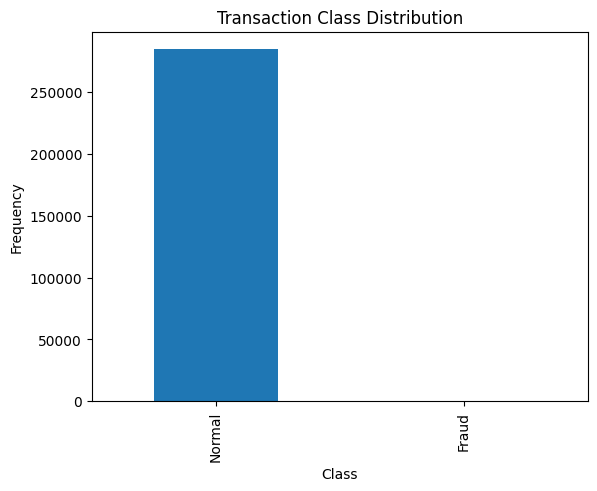

In [ ]:
LABELS = ["Normal", "Fraud"]

count_classes = pd.value_counts(data['Class'], sort = True)
count_classes.plot(kind = 'bar')
plt.title("Transaction Class Distribution")
plt.xticks(range(2), LABELS)
plt.xlabel("Class")
plt.ylabel("Frequency")

import warnings
warnings.filterwarnings('ignore')

In [ ]:
data.Class.value_counts()

,count
Class,
0,284315
1,492


Determine the number of fraud and valid transactions in the entire dataset.

In [ ]:
data.shape

(284807, 31)

In [ ]:
fraud = data[data['Class']==1]
normal = data[data['Class']==0]

print(fraud.shape)
print(normal.shape)

(492, 31)
(284315, 31)


How different are the amount of money used in different transaction classes?

In [ ]:
pd.concat([fraud.Amount.describe(), normal.Amount.describe()], axis=1)

,Amount,Amount
count,492.000000,284315.000000
mean,122.211321,88.291022
std,256.683288,250.105092
min,0.000000,0.000000
25%,1.000000,5.650000
50%,9.250000,22.000000
75%,105.890000,77.050000
max,2125.870000,25691.160000


# Data Pre-processing

`Time` and `Amount` should be scaled as the other columns.

In [ ]:
X = data.drop('Class', axis=1)
y = data.Class

In [ ]:
from sklearn.model_selection import train_test_split

X_train_v, X_test, y_train_v, y_test = train_test_split(X, y,
                                                    test_size=0.3, random_state=42)
X_train, X_validate, y_train, y_validate = train_test_split(X_train_v, y_train_v,
                                                            test_size=0.2, random_state=42)


In [ ]:
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()

X_train = scalar.fit_transform(X_train)
X_validate = scalar.transform(X_validate)
X_test = scalar.transform(X_test)

prop_n = y_train.value_counts()[0] / len(y_train) # proportion of normal
prop_f = y_train.value_counts()[1] / len(y_train) # proportion of fraud

print(f"Non-Fraudulent transaction: {prop_n * 100:.2f}%")
print(f"Fraudulent transaction: {prop_f * 100:.2f}%")

Non-Fraudulent transaction: 99.82%
Fraudulent transaction: 0.18%


In [ ]:
print(X_train.shape)
print(X_validate.shape)
print(X_test.shape)

(159491, 30)
(39873, 30)
(85443, 30)


In [ ]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(X_train.shape[-1],)), #Input shape matches feature size of training data.
    keras.layers.BatchNormalization(), # Normalize the output from the dense layer
    keras.layers.Dropout(0.3),   # deactivate the neurons
    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid'),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,849 (558.00 KB)

 Trainable params: 141,313 (552.00 KB)

 Non-trainable params: 1,536 (6.00 KB)

keras.layers.Dense(256, use_bias=False),     
keras.layers.BatchNormalization(),
keras.layers.Activation('relu'),


No bias tearm, because BatchNorm already includes a shift term (β), so:

The bias in the Dense layer becomes redundant

It just adds unnecessary parameters

In [ ]:
X_train.shape

(159491, 30)

In [ ]:
METRICS = [
    keras.metrics.Accuracy(name='accuracy'),
    #keras.metrics.FalseNegatives(name='fn'),
    #keras.metrics.FalsePositives(name='fp'),
    #keras.metrics.TrueNegatives(name='tn'),
    #keras.metrics.TruePositives(name='tp'),
    #keras.metrics.Precision(name='precision'),
    #keras.metrics.Recall(name='recall')
]

model.compile(optimizer=keras.optimizers.Adam(), loss='binary_crossentropy', metrics=METRICS)

callbacks = [keras.callbacks.ModelCheckpoint('fraud_model_at_epoch_{epoch}.keras')]


r = model.fit(
    X_train, y_train,
    validation_data=(X_validate, y_validate),
    batch_size=2000,
    epochs=20,
    callbacks=callbacks,
)

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.0012 - loss: 0.0033 - val_accuracy: 0.0011 - val_loss: 0.0045
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 9.5354e-04 - loss: 0.0036 - val_accuracy: 0.0018 - val_loss: 0.0057
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.0017 - loss: 0.0031 - val_accuracy: 0.0014 - val_loss: 0.0045
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.0014 - loss: 0.0029 - val_accuracy: 0.0010 - val_loss: 0.0042
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.0012 - loss: 0.0034 - val_accuracy: 0.0017 - val_loss: 0.0042
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.0013 - loss: 0.0023 - val_accuracy: 0.0013 - val_loss: 0.0044
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.0014 - loss: 0.0025 - val_accuracy: 0.0014 - val_loss: 0.0042
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.0015 - loss: 0.0023 - val_accuracy: 8.276

In [ ]:
score = model.evaluate(X_test, y_test)
print(score)

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.0016 - loss: 0.0043
[0.00330336787737906, 0.0014980747364461422]
